<a href="https://colab.research.google.com/github/Princekumarr999777/neetcode-submissions/blob/main/notebookccfe0460f5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

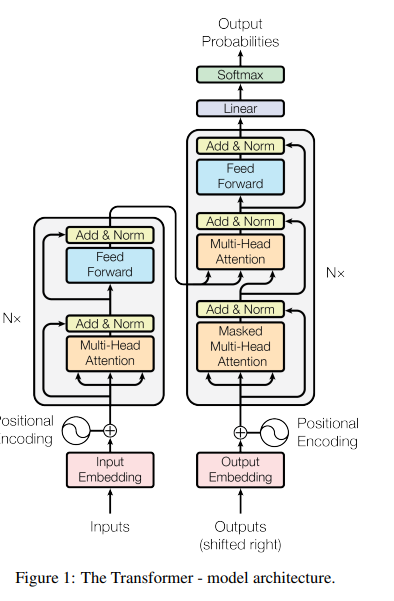

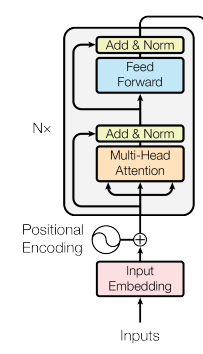

 all the important liberires from pytorch

In [ ]:
import math
import torch
import pathlib
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

2026-05-08 01:50:08.942727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778205009.140592      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778205009.201986      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778205009.689426      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778205009.689481      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778205009.689483      22 computation_placer.cc:177] computation placer alr

In [ ]:
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

In [ ]:
from pathlib import Path
from typing import Any
from tqdm import tqdm
import warnings

EnputEmbedding Class

this is a code to assign a number for each word
eg...is =01,are=02.......

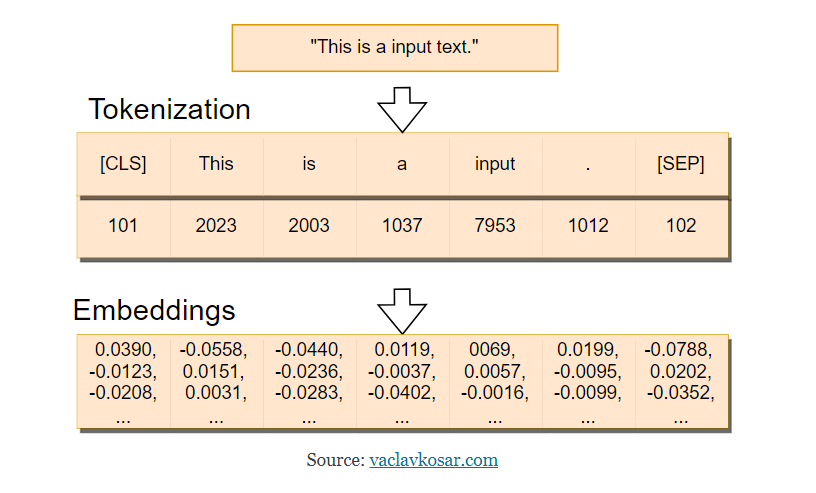



In [ ]:
class InputEmbeddings(nn.Module):
  def __init__(self,d_model:int,vocab_size:int):
    super().__init__()
    self.d_model=d_model
    self.vocab_size=vocab_size
    self.embedding=nn.Embedding(vocab_size,d_model)

  def forward(self,x):
    return self.embedding(x) * math.sqrt(self.d_model)

**Positional** **coding**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
d_model=6
max_sequence_length=11

In [ ]:
pe=torch.zeros(max_sequence_length,d_model)
pe

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])

In [ ]:
pos=torch.arange(max_sequence_length,dtype=torch.float)
pos

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [ ]:
pos=pos.reshape(max_sequence_length,1)
pos

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.]])

In [ ]:
even_i=torch.arange(0,d_model,2)
even_i

tensor([0, 2, 4])

In [ ]:
even_denominator=torch.pow(10000,even_i/d_model)
even_denominator

tensor([  1.0000,  21.5443, 464.1590])

In [ ]:
odd_i=torch.arange(1,d_model,2)
odd_i

tensor([1, 3, 5])

In [ ]:
odd_denominator=torch.pow(10000,(odd_i-1)/d_model)
odd_denominator

tensor([  1.0000,  21.5443, 464.1590])

both denominators give equal results so we can choose anyone for further use

In [ ]:
denominator=even_denominator
denominator

tensor([  1.0000,  21.5443, 464.1590])

In [ ]:
even_PE=torch.sin(pos/denominator)
even_PE

tensor([[ 0.0000,  0.0000,  0.0000],
        [ 0.8415,  0.0464,  0.0022],
        [ 0.9093,  0.0927,  0.0043],
        [ 0.1411,  0.1388,  0.0065],
        [-0.7568,  0.1846,  0.0086],
        [-0.9589,  0.2300,  0.0108],
        [-0.2794,  0.2749,  0.0129],
        [ 0.6570,  0.3192,  0.0151],
        [ 0.9894,  0.3629,  0.0172],
        [ 0.4121,  0.4057,  0.0194],
        [-0.5440,  0.4477,  0.0215]])

In [ ]:
odd_PE=torch.cos(pos/denominator)
odd_PE

tensor([[ 1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.9989,  1.0000],
        [-0.4161,  0.9957,  1.0000],
        [-0.9900,  0.9903,  1.0000],
        [-0.6536,  0.9828,  1.0000],
        [ 0.2837,  0.9732,  0.9999],
        [ 0.9602,  0.9615,  0.9999],
        [ 0.7539,  0.9477,  0.9999],
        [-0.1455,  0.9318,  0.9999],
        [-0.9111,  0.9140,  0.9998],
        [-0.8391,  0.8942,  0.9998]])

now combine both embedding together

In [ ]:
stacked=torch.stack([even_PE,odd_PE],dim=2)
stacked

tensor([[[ 0.0000,  1.0000],
         [ 0.0000,  1.0000],
         [ 0.0000,  1.0000]],

        [[ 0.8415,  0.5403],
         [ 0.0464,  0.9989],
         [ 0.0022,  1.0000]],

        [[ 0.9093, -0.4161],
         [ 0.0927,  0.9957],
         [ 0.0043,  1.0000]],

        [[ 0.1411, -0.9900],
         [ 0.1388,  0.9903],
         [ 0.0065,  1.0000]],

        [[-0.7568, -0.6536],
         [ 0.1846,  0.9828],
         [ 0.0086,  1.0000]],

        [[-0.9589,  0.2837],
         [ 0.2300,  0.9732],
         [ 0.0108,  0.9999]],

        [[-0.2794,  0.9602],
         [ 0.2749,  0.9615],
         [ 0.0129,  0.9999]],

        [[ 0.6570,  0.7539],
         [ 0.3192,  0.9477],
         [ 0.0151,  0.9999]],

        [[ 0.9894, -0.1455],
         [ 0.3629,  0.9318],
         [ 0.0172,  0.9999]],

        [[ 0.4121, -0.9111],
         [ 0.4057,  0.9140],
         [ 0.0194,  0.9998]],

        [[-0.5440, -0.8391],
         [ 0.4477,  0.8942],
         [ 0.0215,  0.9998]]])

In [ ]:
stacked.shape


torch.Size([11, 3, 2])

In [ ]:
PE=torch.flatten(stacked,start_dim=1,end_dim=2)
PE

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957,  0.0043,  1.0000],
        [ 0.1411, -0.9900,  0.1388,  0.9903,  0.0065,  1.0000],
        [-0.7568, -0.6536,  0.1846,  0.9828,  0.0086,  1.0000],
        [-0.9589,  0.2837,  0.2300,  0.9732,  0.0108,  0.9999],
        [-0.2794,  0.9602,  0.2749,  0.9615,  0.0129,  0.9999],
        [ 0.6570,  0.7539,  0.3192,  0.9477,  0.0151,  0.9999],
        [ 0.9894, -0.1455,  0.3629,  0.9318,  0.0172,  0.9999],
        [ 0.4121, -0.9111,  0.4057,  0.9140,  0.0194,  0.9998],
        [-0.5440, -0.8391,  0.4477,  0.8942,  0.0215,  0.9998]])

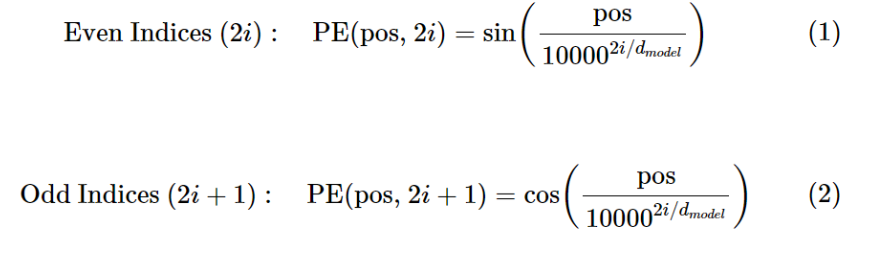

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,d_model:int,max_sequence_length:int,dropout:float):
    super().__init__()
    self.d_model=d_model
    self.seq_len=max_sequence_length
    self.dropout=nn.Dropout(dropout)

    pe=torch.zeros(max_sequence_length,d_model)
    position=torch.arange(0,max_sequence_length,dtype=torch.float).unsqueeze(1)
    div_term=torch.exp(torch.arange(0,d_model,2).float() * (-math.log(10000.0)/d_model))
    pe[:,0::2]=torch.sin(position * div_term)
    pe[:,1::2]=torch.cos(position * div_term)
    pe=pe.unsqueeze(0)
    self.register_buffer('pe',pe)

  def forward(self,x):
    x=x+(self.pe[:,:x.shape[1],:]).requires_grad_(False)
    return self.dropout(x)

Layer Normalization

In [ ]:
class LayerNormalization(nn.Module):
  def __init__(self,eps:float=10**-6):
    super().__init__()
    self.eps=eps
    self.alpha=nn.Parameter(torch.ones(1))
    self.bias=nn.Parameter(torch.zeros(1))

  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    std=x.std(dim=-1,keepdim=True)
    return self.alpha * (x-mean)/(std+self.eps)+ self.bias

Multi Head Attention class

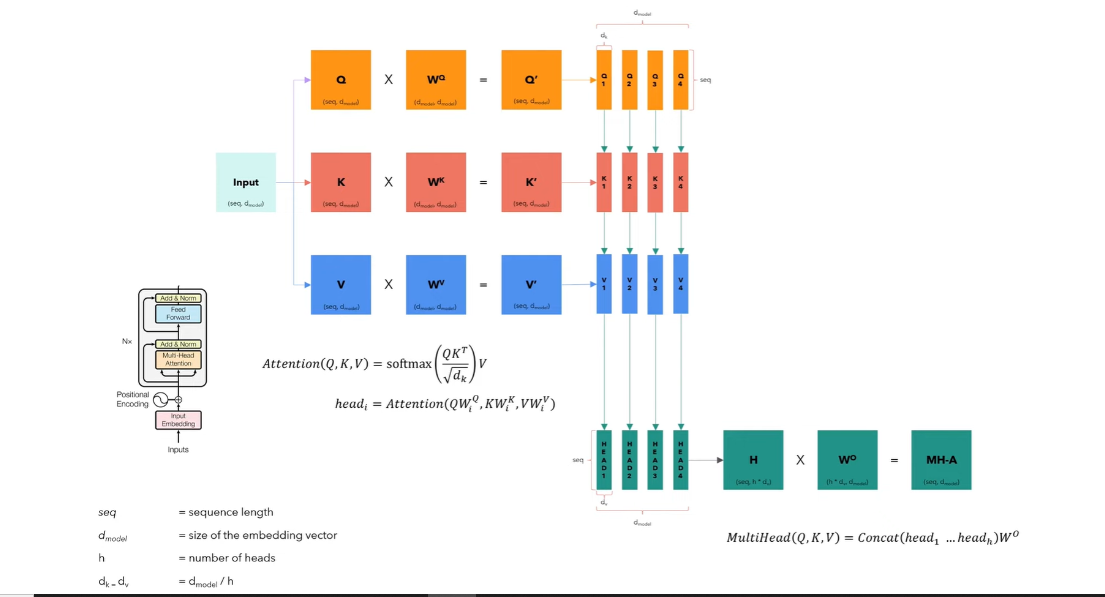

In [ ]:
class MultiHeadAttentionBlock(nn.Module):
  def  __init__(self,d_model:int,h:int,dropout:float) ->None:
    super().__init__()
    self.d_model=d_model
    self.h=h
    assert d_model % h ==0 ,'d_model is not divisible by h '
    self.d_k=d_model//h
    self.w_q=nn.Linear(d_model,d_model)
    self.w_k=nn.Linear(d_model,d_model)
    self.w_v=nn.Linear(d_model,d_model)
    self.w_o=nn.Linear(d_model,d_model)
    self.dropout=nn.Dropout(dropout)


  @staticmethod
  def attention(query,key,value,mask,dropout:nn.Dropout):
    d_k=query.shape[-1]
    attention_scores=(query @ key.transpose(-2,-1)) / math.sqrt(d_k)
    if mask is not None:
     attention_scores.masked_fill_(mask==0 , -1e9)
    attention_scores=attention_scores.softmax(dim=-1)
    attention_scores=dropout(attention_scores)
    return (attention_scores @ value), attention_scores

  def forward(self,q,k,v,mask):
    query=self.w_q(q)
    key=self.w_k(k)
    value=self.w_v(v)
    query=query.view(query.shape[0],query.shape[1],self.h,self.d_k).transpose(1,2)
    key=key.view(key.shape[0],key.shape[1],self.h,self.d_k).transpose(1,2)
    value=value.view(value.shape[0],value.shape[1],self.h,self.d_k).transpose(1,2)
    x, self.attention_scores = MultiHeadAttentionBlock.attention(query,key,value,mask,self.dropout)
    x = x.transpose(1,2).contiguous().view(x.shape[0],-1,self.h * self.d_k)
    return self.w_o(x)

Residual connection


In [ ]:
class ResidualConnection(nn.Module):
    def __init__(self,dropout:float) -> None:
        super().__init__()
        self.dropout=nn.Dropout(dropout)
        self.norm=LayerNormalization()

    def forward(self,x,sublayer):
      return x+self.dropout(sublayer(self.norm(x)))

feedforward neural network

In [ ]:
class FeedForwardBlock(nn.Module):
  def __init__(self,d_model:int,d_ff:int,dropout:float):
    super().__init__()
    self.linear_1=nn.Linear(d_model,d_ff)
    self.dropout=nn.Dropout(dropout)
    self.linear_2=nn.Linear(d_ff,d_model)

  def forward (self,x):
    return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))

Encoder block
(stack = 6  identity layer)and (2 sublayer)

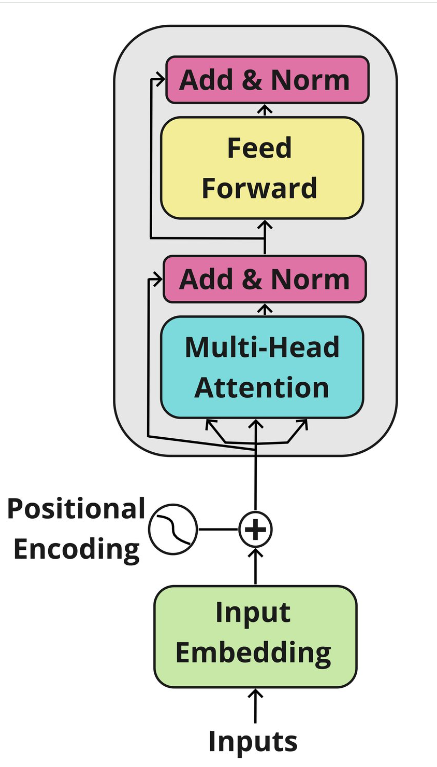

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,self_attention_block:MultiHeadAttentionBlock,feed_forward_block:FeedForwardBlock,dropout:float)  ->None:
    super().__init__()
    self.self_attention_block=self_attention_block
    self.feed_forward_block=feed_forward_block
    self.residual_connections=nn.ModuleList([ResidualConnection(dropout) for _ in range(2)])

  def forward(self,x,src_mask):
    x=self.residual_connections[0](x,lambda x:self.self_attention_block(x,x,x,src_mask))
    x=self.residual_connections[1](x,self.feed_forward_block)
    return x

encoder

In [ ]:
class Encoder(nn.Module):
  def __init__(self,layers:nn.ModuleList)  ->None:
    super().__init__()
    self.layers=layers
    self.norm=LayerNormalization()
  def forward(self,x,mask):
    for Layer in self.layers:
      x=Layer(x,mask)
    return self.norm(x)

Decoder block

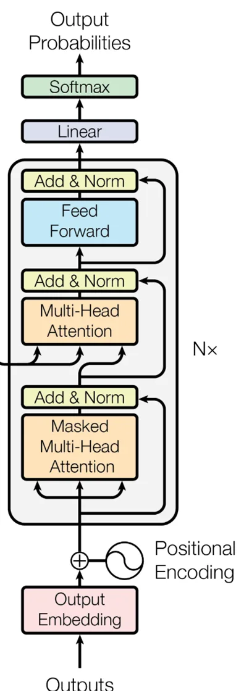

In [ ]:
class DecoderBlock(nn.Module):
 def __init__(self,self_attention_block:MultiHeadAttentionBlock,cross_attention_block:MultiHeadAttentionBlock,feed_forward_block:FeedForwardBlock,dropout:float)  ->None :
    super().__init__()
    self.self_attention_block=self_attention_block
    self.cross_attention_block=cross_attention_block
    self.feed_forward_block=feed_forward_block
    self.residual_connections=nn.ModuleList([ResidualConnection(dropout) for  _ in range(3)])
 def forward(self,x,encoder_output,src_mask,tgt_mask):
      x=self.residual_connections[0](x,lambda x:self.self_attention_block(x,x,x,tgt_mask))
      x=self.residual_connections[1](x,lambda x:self.cross_attention_block(x,encoder_output,encoder_output,src_mask))
      x=self.residual_connections[2](x,self.feed_forward_block)
      return x

Decoder

In [ ]:
class Decoder(nn.Module):
  def __init__(self,layers:nn.ModuleList)  ->None:
    super().__init__()
    self.layers=layers
    self.norm=LayerNormalization()
  def forward(self,x,encoder_output,src_mask,tgt_mask):
    for layer in self.layers:
      x=layer(x,encoder_output,src_mask,tgt_mask)
    return self.norm(x)

linear layer after decoder and encoder

In [ ]:
class ProjectionLayer(nn.Module):
  def __init__(self,d_model:int,vocab_size:int) -> None:
    super().__init__()
    self.proj=nn.Linear(d_model,vocab_size)
  def forward(self,x):
    return torch.log_softmax(self.proj(x),dim=-1)

Building the transformer

In [ ]:
class Transformer(nn.Module):
  def __init__(self,encoder:Encoder,decoder:Decoder,src_embed:InputEmbeddings,tgt_embed:InputEmbeddings,src_pos:PositionalEncoding,tgt_pos:PositionalEncoding,projection_layer:ProjectionLayer)  -> None:
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.src_embed=src_embed
    self.tgt_embed=tgt_embed
    self.src_pos=src_pos
    self.tgt_pos=tgt_pos
    self.projection_layer=projection_layer

  def encode(self, src, src_mask):
      src = self.src_embed(src)
      src = self.src_pos(src)
      return self.encoder(src, src_mask)

  def decode(self, encoder_output, src_mask, tgt, tgt_mask):
      tgt = self.tgt_embed(tgt)
      tgt = self.tgt_pos(tgt)
      return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

  def project(self, x):
      return self.projection_layer(x)

In [ ]:
def build_transformer(src_vocab_size:int,tgt_vocab_size:int,src_seq_len:int,tgt_seq_len:int,d_model:int=512,N:int=6,h:int=8,dropout:float=0.1,dff:int=2048) ->Transformer:
      src_embed=InputEmbeddings(d_model,src_vocab_size)
      tgt_embed=InputEmbeddings(d_model,tgt_vocab_size)
      src_pos=PositionalEncoding(d_model,src_seq_len,dropout)
      tgt_pos=PositionalEncoding(d_model,tgt_seq_len,dropout)
      encoder_blocks=[]
      for _ in range(N):
            encoder_self_attention_block=MultiHeadAttentionBlock(d_model,h,dropout)
            feed_forward_block=FeedForwardBlock(d_model,dff,dropout)
            encoder_block=EncoderBlock(encoder_self_attention_block,feed_forward_block,dropout)
            encoder_blocks.append(encoder_block)

      decoder_blocks=[]
      for _ in range(N):
            decoder_self_attention_block=MultiHeadAttentionBlock(d_model,h,dropout)
            decoder_cross_attention_block=MultiHeadAttentionBlock(d_model,h,dropout)
            feed_forward_block=FeedForwardBlock(d_model,dff,dropout)
            decoder_block=DecoderBlock(decoder_self_attention_block,decoder_cross_attention_block,feed_forward_block,dropout)
            decoder_blocks.append(decoder_block)
      encoder=Encoder(nn.ModuleList(encoder_blocks))
      decoder=Decoder(nn.ModuleList(decoder_blocks))
      projection_layer=ProjectionLayer(d_model,tgt_vocab_size)
      transformer=Transformer(encoder,decoder,src_embed,tgt_embed,src_pos,tgt_pos,projection_layer)
      for p in transformer.parameters():
        if p.dim()>1:
          nn.init.xavier_uniform_(p)

      return transformer

Test our transformer<br>
1.Tokenizer

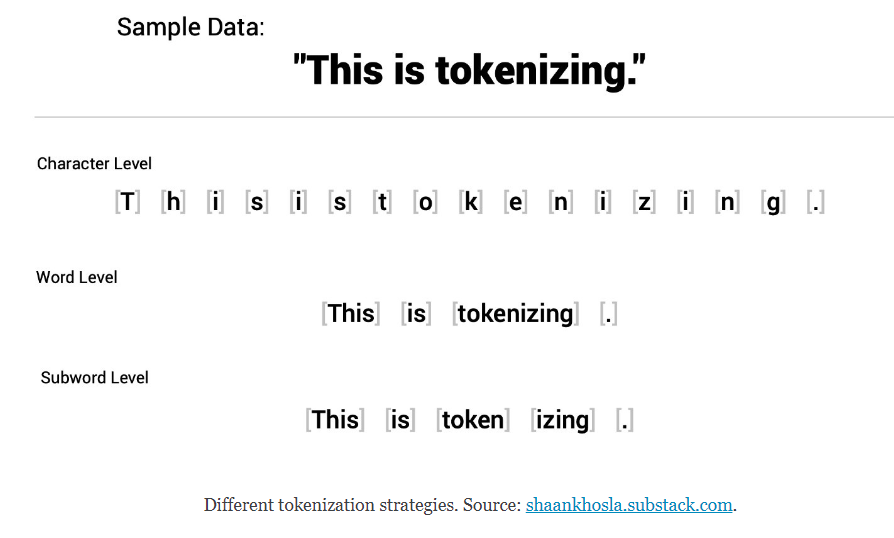

Loading dataset

casual mask


Validation loop

In [ ]:
def build_tokenizer(config, ds, lang):

    tokenizer_path = Path(config['tokenizer_file'].format(lang))

    if not Path.exists(tokenizer_path):

        tokenizer = Tokenizer(WordLevel(unk_token = '[UNK]'))
        tokenizer.pre_tokenizer = Whitespace()

        trainer = WordLevelTrainer(special_tokens = ["[UNK]", "[PAD]",
                                                     "[SOS]", "[EOS]"], min_frequency = 2)

        tokenizer.train_from_iterator(get_all_sentences(ds, lang), trainer = trainer)
        tokenizer.save(str(tokenizer_path))
    else:
        tokenizer = Tokenizer.from_file(str(tokenizer_path))
    return tokenizer

In [ ]:
def get_all_sentences(ds, lang):
    for pair in ds:
        yield pair['translation'][lang]

In [ ]:
def get_ds(config):

    ds_raw = load_dataset('opus_books', f'{config["lang_src"]}-{config["lang_tgt"]}', split = 'train')

    tokenizer_src = build_tokenizer(config, ds_raw, config['lang_src'])
    tokenizer_tgt = build_tokenizer(config, ds_raw, config['lang_tgt'])

    train_ds_size = int(0.9 * len(ds_raw))
    val_ds_size = len(ds_raw) - train_ds_size
    train_ds_raw, val_ds_raw = random_split(ds_raw, [train_ds_size, val_ds_size])

    train_ds = BilingualDataset(train_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])
    val_ds = BilingualDataset(val_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])

    max_len_src = 0
    max_len_tgt = 0
    for pair in ds_raw:
        src_ids = tokenizer_src.encode(pair['translation'][config['lang_src']]).ids
        tgt_ids = tokenizer_src.encode(pair['translation'][config['lang_tgt']]).ids
        max_len_src = max(max_len_src, len(src_ids))
        max_len_tgt = max(max_len_tgt, len(tgt_ids))

    print(f'Max length of source sentence: {max_len_src}')
    print(f'Max length of target sentence: {max_len_tgt}')

    train_dataloader = DataLoader(train_ds, batch_size = config['batch_size'], shuffle = True)
    val_dataloader = DataLoader(val_ds, batch_size = 1, shuffle = True)

    return train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt

In [ ]:
def translate_sentence(model, sentence: str, tokenizer_src, tokenizer_tgt, config):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device for translation: {device}")

    enc_input_tokens = tokenizer_src.encode(sentence).ids

    print(f"translate_sentence: Encoded input tokens (IDs): {enc_input_tokens}")
    print(f"translate_sentence: Max token ID in sentence: {max(enc_input_tokens) if enc_input_tokens else 'N/A'}")
    print(f"translate_sentence: Source tokenizer vocab size: {tokenizer_src.get_vocab_size()}")

    num_padding_tokens = config['seq_len'] - len(enc_input_tokens) - 2
    if num_padding_tokens < 0:
        print(f"Warning: Sentence length ({len(enc_input_tokens) + 2}) exceeds seq_len ({config['seq_len']}). Truncating or padding will be incorrect.")
        num_padding_tokens = 0

    encoder_input = torch.cat(
        [
            torch.tensor([tokenizer_src.token_to_id('[SOS]')], dtype=torch.int64),
            torch.tensor(enc_input_tokens, dtype=torch.int64),
            torch.tensor([tokenizer_src.token_to_id('[EOS]')], dtype=torch.int64),
            torch.full((num_padding_tokens,), tokenizer_src.token_to_id('[PAD]'), dtype=torch.int64)
        ]
    ).unsqueeze(0).to(device)

    encoder_mask = (encoder_input != tokenizer_src.token_to_id('[PAD]')).unsqueeze(0).unsqueeze(0).int().to(device)

    model_output_tokens = greedy_decode(model, encoder_input, encoder_mask, tokenizer_src, tokenizer_tgt, config['seq_len'], device)

    translated_text = tokenizer_tgt.decode(model_output_tokens.detach().cpu().numpy())

    return translated_text

TRAINING LOOP

### Test Translation

In [ ]:
def casual_mask(size):
        mask = torch.triu(torch.ones(1, size, size), diagonal = 1).type(torch.int)
        return mask == 0

In [ ]:
class BilingualDataset(Dataset):

    def __init__(self, ds, tokenizer_src, tokenizer_tgt, src_lang, tgt_lang, seq_len) -> None:
        super().__init__()

        self.seq_len = seq_len
        self.ds = ds
        self.tokenizer_src = tokenizer_src
        self.tokenizer_tgt = tokenizer_tgt
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

        self.sos_token = torch.tensor([tokenizer_tgt.token_to_id("[SOS]")], dtype=torch.int64)
        self.eos_token = torch.tensor([tokenizer_tgt.token_to_id("[EOS]")], dtype=torch.int64)
        self.pad_token = torch.tensor([tokenizer_tgt.token_to_id("[PAD]")], dtype=torch.int64)


    def __len__(self):
        return len(self.ds)

    def __getitem__(self, index: Any) -> Any:
        src_target_pair = self.ds[index]
        src_text = src_target_pair['translation'][self.src_lang]
        tgt_text = src_target_pair['translation'][self.tgt_lang]

        enc_input_tokens = self.tokenizer_src.encode(src_text).ids
        dec_input_tokens = self.tokenizer_tgt.encode(tgt_text).ids

        enc_num_padding_tokens = self.seq_len - len(enc_input_tokens) - 2
        dec_num_padding_tokens = self.seq_len - len(dec_input_tokens) - 1

        if enc_num_padding_tokens < 0 or dec_num_padding_tokens < 0:
            raise ValueError('Sentence is too long')

        encoder_input = torch.cat(
            [
            self.sos_token,
            torch.tensor(enc_input_tokens, dtype = torch.int64),
            self.eos_token,
            torch.tensor([self.pad_token] * enc_num_padding_tokens, dtype = torch.int64)
            ]
        )

        decoder_input = torch.cat(
            [
                self.sos_token,
                torch.tensor(dec_input_tokens, dtype = torch.int64),
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype = torch.int64)
            ]

        )

        label = torch.cat(
            [
                torch.tensor(dec_input_tokens, dtype = torch.int64),
                self.eos_token,
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype = torch.int64)

            ]
        )

        assert encoder_input.size(0) == self.seq_len
        assert decoder_input.size(0) == self.seq_len
        assert label.size(0) == self.seq_len

        return {
            'encoder_input': encoder_input,
            'decoder_input': decoder_input,
            'encoder_mask': (encoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int(),
            'decoder_mask': (decoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int() & casual_mask(decoder_input.size(0)),
            'label': label,
            'src_text': src_text,
            'tgt_text': tgt_text
        }

In [ ]:
def greedy_decode(model, source, source_mask, tokenizer_src, tokenizer_tgt, max_len, device):
    sos_idx = tokenizer_tgt.token_to_id('[SOS]')
    eos_idx = tokenizer_tgt.token_to_id('[EOS]')

    encoder_output = model.encode(source, source_mask)
    decoder_input = torch.empty(1,1).fill_(sos_idx).type_as(source).to(device)

    while True:
        if decoder_input.size(1) == max_len:
            break

        decoder_mask = casual_mask(decoder_input.size(1)).type_as(source_mask).to(device)

        out = model.decode(encoder_output, source_mask, decoder_input, decoder_mask)

        prob = model.project(out[:, -1])

        _, next_word = torch.max(prob, dim=1)
        decoder_input = torch.cat([decoder_input, torch.empty(1,1). type_as(source).fill_(next_word.item()).to(device)], dim=1)

        if next_word == eos_idx:
            break

    return decoder_input.squeeze(0)

In [ ]:
def get_ds(config):

    ds_raw = load_dataset('opus_books', f'{config["lang_src"]}-{config["lang_tgt"]}', split = 'train')

    tokenizer_src = build_tokenizer(config, ds_raw, config['lang_src'])
    tokenizer_tgt = build_tokenizer(config, ds_raw, config['lang_tgt'])

    train_ds_size = int(0.9 * len(ds_raw))
    val_ds_size = len(ds_raw) - train_ds_size
    train_ds_raw, val_ds_raw = random_split(ds_raw, [train_ds_size, val_ds_size])

    train_ds = BilingualDataset(train_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])
    val_ds = BilingualDataset(val_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])

    max_len_src = 0
    max_len_tgt = 0
    for pair in ds_raw:
        src_ids = tokenizer_src.encode(pair['translation'][config['lang_src']]).ids
        tgt_ids = tokenizer_src.encode(pair['translation'][config['lang_tgt']]).ids
        max_len_src = max(max_len_src, len(src_ids))
        max_len_tgt = max(max_len_tgt, len(tgt_ids))

    print(f'Max length of source sentence: {max_len_src}')
    print(f'Max length of target sentence: {max_len_tgt}')

    train_dataloader = DataLoader(train_ds, batch_size = config['batch_size'], shuffle = True)
    val_dataloader = DataLoader(val_ds, batch_size = 1, shuffle = True)

    return train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt

In [ ]:
def run_validation(model, validation_ds, tokenizer_src, tokenizer_tgt, max_len, device, print_msg, global_state, writer, num_examples=2):
    model.eval()
    count = 0

    console_width = 80

    with torch.no_grad():
        for batch in validation_ds:
            count += 1
            encoder_input = batch['encoder_input'].to(device)
            encoder_mask = batch['encoder_mask'].to(device)

            assert encoder_input.size(0) ==  1, 'Batch size must be 1 for validation.'

            model_out = greedy_decode(model, encoder_input, encoder_mask, tokenizer_src, tokenizer_tgt, max_len, device)

            source_text = batch['src_text'][0]
            target_text = batch['tgt_text'][0]
            model_out_text = tokenizer_tgt.decode(model_out.detach().cpu().numpy())

            print_msg('-'*console_width)
            print_msg(f'SOURCE: {source_text}')
            print_msg(f'TARGET: {target_text}')
            print_msg(f'PREDICTED: {model_out_text}')

            if count == num_examples:
                break

In [ ]:
def run_validation(model, validation_ds, tokenizer_src, tokenizer_tgt, max_len, device, print_msg, global_step, writer, loss_fn, num_examples=2):
    model.eval()
    count = 0

    # Initialize validation loss tracking
    total_val_loss = 0
    num_val_batches = 0

    console_width = 80

    with torch.no_grad():
        for batch in validation_ds:
            count += 1
            encoder_input = batch['encoder_input'].to(device)
            encoder_mask = batch['encoder_mask'].to(device)
            label = batch['label'].to(device) # Get the true labels for loss calculation

            assert encoder_input.size(0) ==  1, 'Batch size must be 1 for validation.'

            # For validation loss, we need to pass the decoder_input to the model
            # and then compute the loss on the output vs the label.
            # We use the greedy_decode to get the predicted sequence for printing,
            # but for loss, we'll use the model's direct output with decoder_input.

            # Prepare decoder input for loss calculation
            decoder_input_val = batch['decoder_input'].to(device)
            decoder_mask_val = batch['decoder_mask'].to(device)

            # Get model output for loss calculation
            encoder_output_val = model.encode(encoder_input, encoder_mask)
            decoder_output_val = model.decode(encoder_output_val, encoder_mask, decoder_input_val, decoder_mask_val)
            proj_output_val = model.project(decoder_output_val)

            # Calculate validation loss
            loss = loss_fn(proj_output_val.view(-1, tokenizer_tgt.get_vocab_size()), label.view(-1))
            total_val_loss += loss.item()
            num_val_batches += 1

            # Perform greedy decode for translation example
            model_out = greedy_decode(model, encoder_input, encoder_mask, tokenizer_src, tokenizer_tgt, max_len, device)

            source_text = batch['src_text'][0]
            target_text = batch['tgt_text'][0]
            model_out_text = tokenizer_tgt.decode(model_out.detach().cpu().numpy())

            print_msg('-'*console_width)
            print_msg(f'SOURCE: {source_text}')
            print_msg(f'TARGET: {target_text}')
            print_msg(f'PREDICTED: {model_out_text}')
            print_msg(f'VAL LOSS (example): {loss.item():.3f}')

            if count == num_examples:
                break

        # Log average validation loss after the epoch
        if num_val_batches > 0:
            avg_val_loss = total_val_loss / num_val_batches
            writer.add_scalar('val loss', avg_val_loss, global_step)
            print_msg(f'Average Validation Loss: {avg_val_loss:.3f}')
        writer.flush()

In [ ]:
def get_model(config, vocab_src_len, vocab_tgt_len):

    model = build_transformer(vocab_src_len, vocab_tgt_len, config['seq_len'], config['seq_len'], config['d_model'])
    return model

Configuration for our model

In [ ]:
def get_config():
    return{
        'batch_size': 16,
        'num_epochs': 20,
        'lr': 5e-5,
        'seq_len': 350,
        'd_model': 512,
        'lang_src': 'en',
        'lang_tgt': 'it',
        'model_folder': 'weights',
        'model_basename': 'tmodel_',
        'preload': None,
        'tokenizer_file': 'tokenizer_{0}.json',
        'experiment_name': 'runs/tmodel'
    }


def get_weights_file_path(config, epoch: str):
    model_folder = config['model_folder']
    model_basename = config['model_basename']
    model_filename = f"{model_basename}{epoch}.pt"
    return str(Path('.')/ model_folder/ model_filename)

Training of Model

In [ ]:
def train_model(config):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device {device}")

    Path(config['model_folder']).mkdir(parents=True, exist_ok=True)

    train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt = get_ds(config)

    model = get_model(config,tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size()).to(device)

    writer = SummaryWriter(config['experiment_name'])

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], eps = 1e-9)

    initial_epoch = 0
    global_step = 0

    if config['preload']:
        model_filename = get_weights_file_path(config, config['preload'])
        print(f'Preloading model {model_filename}')
        state = torch.load(model_filename)

        initial_epoch = state['epoch'] + 1
        optimizer.load_state_dict(state['optimizer_state_dict'])
        global_step = state['global_step']

    loss_fn = nn.CrossEntropyLoss(ignore_index = tokenizer_tgt.token_to_id('[PAD]'), label_smoothing = 0.1).to(device);

    for epoch in range(initial_epoch, config['num_epochs']):

        batch_iterator = tqdm(train_dataloader, desc = f'Processing epoch {epoch:02d}')

        for batch in batch_iterator:
            model.train()

            encoder_input = batch['encoder_input'].to(device)
            decoder_input = batch['decoder_input'].to(device)
            encoder_mask = batch['encoder_mask'].to(device)
            decoder_mask = batch['decoder_mask'].to(device)

            encoder_output = model.encode(encoder_input, encoder_mask);
            decoder_output = model.decode(encoder_output, encoder_mask, decoder_input, decoder_mask);
            proj_output = model.project(decoder_output)

            label = batch['label'].to(device)

            loss = loss_fn(proj_output.view(-1, tokenizer_tgt.get_vocab_size()), label.view(-1))

            batch_iterator.set_postfix({f"loss": f"{loss.item():6.3f}"})

            writer.add_scalar('train loss', loss.item(), global_step)
            writer.flush()

            loss.backward()

            optimizer.step()

            optimizer.zero_grad()

            global_step += 1

        run_validation(model, val_dataloader, tokenizer_src, tokenizer_tgt, config['seq_len'], device, lambda msg: batch_iterator.write(msg), global_step, writer, loss_fn)

        model_filename = get_weights_file_path(config, f'{epoch:02d}')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'global_step': global_step
        }, model_filename)

In [ ]:
if __name__ == '__main__':
    warnings.filterwarnings('ignore')
    config = get_config()
    train_model(config)

Using device cuda


README.md: 0.00B [00:00, ?B/s]

en-it/train-00000-of-00001.parquet:   0%|          | 0.00/5.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32332 [00:00<?, ? examples/s]

Max length of source sentence: 309
Max length of target sentence: 274


...

--------------------------------------------------------------------------------
SOURCE: I am made that way. And really so little harm is done to anyone, and one gets so much pleasure...'
TARGET: E invero, con questo si fa tanto poco male a qualcuno e tanto piacere a se stesso.
PREDICTED: E sono così disposto a parlare , ma è così poco difficile a nessuno .
VAL LOSS (example): 5.100
--------------------------------------------------------------------------------
SOURCE: Where are the ten?
TARGET: I dieci dove sono?
PREDICTED: Dove sono dieci ?
VAL LOSS (example): 4.873
Average Validation Loss: 4.987


Processing epoch 18: 100%|██████████| 1819/1819 [25:40<00:00,  1.18it/s, loss=3.088]


--------------------------------------------------------------------------------
SOURCE: 'A fine day, your Majesty!' the Duchess began in a low, weak voice.
TARGET: — Maestà che bella giornata! — balbettò la Duchessa con voce bassa e fioca.
PREDICTED: — Un giorno , signorina , — cominciò la Duchessa con voce bassa , basso la voce .
VAL LOSS (example): 4.174
--------------------------------------------------------------------------------
SOURCE: As with the maid she felt not exactly ashamed but uncomfortable about the patches, so with him she felt not exactly ashamed but ill-at-ease about herself.
TARGET: Come dinanzi alla cameriera, non che si vergognasse, ma non si sentiva a suo agio per i rammendi, così di continuo, anche con lui, non che si vergognasse, ma si sentiva a disagio per se stessa.
PREDICTED: Come , con la cameriera non si sentiva che gli altri correvano ; ma a lui , così cercava di non nulla .
VAL LOSS (example): 4.930
Average Validation Loss: 4.552


Processing epoch 19: 100%|██████████| 1819/1819 [25:40<00:00,  1.18it/s, loss=3.236]


--------------------------------------------------------------------------------
SOURCE: She gave the order to harness another pair of horses, and busied herself packing her handbag with things necessary for a few days.
TARGET: Ordinò di attaccare altri cavalli e si occupò di mettere in una sacca da viaggio le cose indispensabili per qualche giorno.
PREDICTED: Ella diede il bagno a prendere un altro paio di cavalli , il movimento , le dette in pochi giorni per il suo ritorno .
VAL LOSS (example): 5.261
--------------------------------------------------------------------------------
SOURCE: First, she tried to look down and make out what she was coming to, but it was too dark to see anything; then she looked at the sides of the well, and noticed that they were filled with cupboards and book-shelves; here and there she saw maps and pictures hung upon pegs.
TARGET: Aguzzò gli occhi, e cercò di fissare il fondo, per scoprire qualche cosa; ma in fondo era buio pesto e non si scopriva nulla.

In [1]:
!git clone https://github.com/Princekumarr999777/transformer-from-scratch.git

Cloning into 'transformer-from-scratch'...


In [2]:
%cd /content/transformer-from-scratch

/content/transformer-from-scratch


In [3]:
!ls -a

.  ..  .git


In [13]:
!find /content -name "*.ipynb"

In [14]:
!pwd

/content/transformer-from-scratch


In [16]:
%cd /content

/content


In [18]:
!ls

sample_data  transformer-from-scratch


In [17]:
!find /content -name "notebookccfe0460f5.ipynb"